# Payment system BCRP

In [53]:
import sys
from functools import reduce

import numpy as np
import pandas as pd
import requests

sys.path.append("..")
sys.path.append("../..")
import catppuccin
import matplotlib.pyplot as plt

from src.utils import build_bcrp_dataset, get_bcrp_clean_series

pd.options.display.float_format = "{:,.2f}".format
pd.set_option("display.max_columns", None)

# TODO: create a visualization.py
plt.style.use("mocha")

In [37]:
plt.style.available

['Solarize_Light2',
 '_classic_test_patch',
 '_mpl-gallery',
 '_mpl-gallery-nogrid',
 'bmh',
 'classic',
 'dark_background',
 'fast',
 'fivethirtyeight',
 'ggplot',
 'grayscale',
 'petroff10',
 'seaborn-v0_8',
 'seaborn-v0_8-bright',
 'seaborn-v0_8-colorblind',
 'seaborn-v0_8-dark',
 'seaborn-v0_8-dark-palette',
 'seaborn-v0_8-darkgrid',
 'seaborn-v0_8-deep',
 'seaborn-v0_8-muted',
 'seaborn-v0_8-notebook',
 'seaborn-v0_8-paper',
 'seaborn-v0_8-pastel',
 'seaborn-v0_8-poster',
 'seaborn-v0_8-talk',
 'seaborn-v0_8-ticks',
 'seaborn-v0_8-white',
 'seaborn-v0_8-whitegrid',
 'tableau-colorblind10']

1. understand why similar card series appear in different sections.
2. Milestone 2 — Replicate BCRP Charts
3. Milestone 3 — Define Culqi Market

In [3]:
metadata = pd.read_csv("../../data/BCRPData-metadata.csv", encoding="latin1", sep=";")

## Instrumentos de pagos de alto y bajo valor: Monto de operaciones (Millones de Soles)

In [4]:
codes_names = {
    "PN42156EM": "alto_valor",
    "PN42157EM": "alto_valor_lbtr",
    "PN42158EM": "alto_valor_lbtr_clientes",
    "PN42159EM": "alto_valor_lbtr_propias",
    "PN42160EM": "bajo_valor",
    "PN42161EM": "bajo_valor_cheques",
    "PN42162EM": "bajo_valor_cheques_intrabancarios",
    "PN42163EM": "bajo_valor_cheques_interbancarios_cce",
    "PN42164EM": "bajo_valor_tarjetas_pago",
    "PN42165EM": "bajo_valor_tarjetas_debito",
    "PN42166EM": "bajo_valor_tarjetas_debito_no_presencial",
    "PN42167EM": "bajo_valor_tarjetas_debito_presencial",
    "PN42168EM": "bajo_valor_tarjetas_credito",
    "PN42169EM": "bajo_valor_tarjetas_credito_no_presencial",
    "PN42170EM": "bajo_valor_tarjetas_credito_presencial",
    "PN42171EM": "bajo_valor_transferencias_intrabancarias",
    "PN42172EM": "bajo_valor_transferencias_intrabancarias_no_presencial",
    "PN42173EM": "bajo_valor_transferencias_intrabancarias_presencial",
    "PN42174EM": "bajo_valor_transferencias_interbancarias",
    "PN42175EM": "bajo_valor_transferencias_cce",
    "PN42176EM": "bajo_valor_pagos_inmediatos",
    "PN42177EM": "bajo_valor_pagos_inmediatos_cce",
    "PN42178EM": "bajo_valor_pagos_inmediatos_visa_direct",
    "PN42179EM": "bajo_valor_debitos_directos",
    "PN42180EM": "bajo_valor_dinero_electronico",
    "PN42181EM": "indicador_pagos_digitales",
    "PN42182EM": "retiro_efectivo",
    "PN42183EM": "retiro_efectivo_tarjetas_debito",
    "PN42184EM": "retiro_efectivo_tarjetas_credito",
}

In [5]:
df_instr_alto_bajo_valor = build_bcrp_dataset(codes_names)

In [12]:
df_instr_alto_bajo_valor.head(5)

,period,alto_valor,alto_valor_lbtr,alto_valor_lbtr_clientes,alto_valor_lbtr_propias,bajo_valor,bajo_valor_cheques,bajo_valor_cheques_intrabancarios,bajo_valor_cheques_interbancarios_cce,bajo_valor_tarjetas_pago,bajo_valor_tarjetas_debito,bajo_valor_tarjetas_debito_no_presencial,bajo_valor_tarjetas_debito_presencial,bajo_valor_tarjetas_credito,bajo_valor_tarjetas_credito_no_presencial,bajo_valor_tarjetas_credito_presencial,bajo_valor_transferencias_intrabancarias,bajo_valor_transferencias_intrabancarias_no_presencial,bajo_valor_transferencias_intrabancarias_presencial,bajo_valor_transferencias_interbancarias,bajo_valor_transferencias_cce,bajo_valor_pagos_inmediatos,bajo_valor_pagos_inmediatos_cce,bajo_valor_pagos_inmediatos_visa_direct,bajo_valor_debitos_directos,bajo_valor_dinero_electronico,indicador_pagos_digitales,retiro_efectivo,retiro_efectivo_tarjetas_debito,retiro_efectivo_tarjetas_credito
0,2026-03-01,"478,458.55","478,458.55","276,217.63","202,240.93","417,155.45","17,286.21","8,994.63","8,291.58","19,878.20","9,287.07","3,361.15","5,925.92","10,591.13","2,809.84","7,781.29","306,213.06","288,301.87","17,911.20","70,454.61","31,624.16","38,830.45","26,298.41","12,532.04",943.81,"2,379.56","676,086.86","42,129.57","41,414.49",715.07
1,2026-02-01,"411,779.84","411,779.84","241,547.00","170,232.84","377,297.19","15,190.19","7,900.70","7,289.49","17,366.34","8,126.11","3,018.39","5,107.71","9,240.23","2,407.17","6,833.06","281,644.01","266,454.34","15,189.67","60,294.64","25,975.08","34,319.55","23,196.57","11,122.98",896.30,"1,905.71","603,654.01","37,964.07","37,355.89",608.18
2,2026-01-01,"398,930.84","398,930.84","237,217.90","161,712.94","394,384.29","14,677.73","8,119.94","6,557.80","18,073.66","8,557.64","3,165.87","5,391.77","9,516.03","2,466.78","7,049.25","296,144.76","280,040.98","16,103.78","62,649.15","27,001.48","35,647.67","24,075.79","11,571.87",950.83,"1,888.15","616,924.45","41,511.94","40,875.96",635.98
3,2025-12-01,"462,444.46","462,444.46","291,465.35","170,979.12","458,953.59","15,595.36","9,699.58","5,895.78","20,981.01","10,085.39","3,397.48","6,687.91","10,895.62","2,450.10","8,445.51","347,521.02","328,208.00","19,313.02","71,907.60","32,307.77","39,599.83","25,722.70","13,877.13",922.75,"2,025.85","734,823.58","45,138.12","44,511.74",626.39
4,2025-11-01,"398,541.09","398,541.09","226,164.46","172,376.63","374,481.11","14,329.00","7,705.44","6,623.55","17,752.58","7,940.23","2,898.00","5,042.23","9,812.35","2,708.62","7,103.73","276,351.80","259,990.56","16,361.23","63,362.31","28,139.77","35,222.55","23,667.14","11,555.41",904.13,"1,781.30","586,316.58","38,331.71","37,694.75",636.96


In [ ]:
df_instr_alto_bajo_valor["bajo_valor_calculated"] = df_instr_alto_bajo_valor[
    [
        "bajo_valor_cheques",
        "bajo_valor_tarjetas_pago",
        "bajo_valor_transferencias_intrabancarias",
        "bajo_valor_transferencias_interbancarias",
        "bajo_valor_debitos_directos",
        "bajo_valor_dinero_electronico",
    ]
].sum(axis=1)
df_instr_alto_bajo_valor["residual"] = (
    df_instr_alto_bajo_valor["bajo_valor"]
    - df_instr_alto_bajo_valor["bajo_valor_calculated"]
)

In [29]:
df_instr_alto_bajo_valor[
    ["period", "bajo_valor", "bajo_valor_calculated", "residual"]
].head(5)

,period,bajo_valor,bajo_valor_calculated,residual
0,2026-03-01,"417,155.45","417,155.45",-0.00
1,2026-02-01,"377,297.19","377,297.19",0.00
2,2026-01-01,"394,384.29","394,384.29",0.00
3,2025-12-01,"458,953.59","458,953.59",-0.00
4,2025-11-01,"374,481.11","374,481.11",0.00


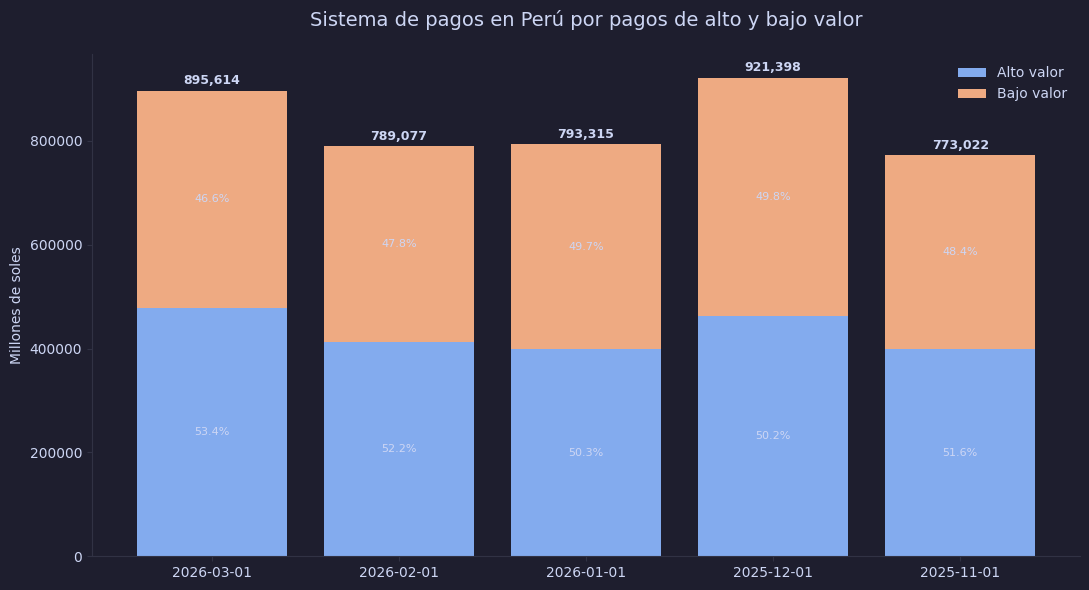

In [41]:
df_plot = (
    df_instr_alto_bajo_valor[["period", "alto_valor", "bajo_valor"]]
    .query("period >= '2025-11-01'")
    .copy()
)

df_plot["total"] = df_plot["alto_valor"] + df_plot["bajo_valor"]

fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    df_plot["period"].astype(str), df_plot["alto_valor"], label="Alto valor", alpha=0.95
)

ax.bar(
    df_plot["period"].astype(str),
    df_plot["bajo_valor"],
    bottom=df_plot["alto_valor"],
    label="Bajo valor",
    alpha=0.95,
)

for i, row in df_plot.reset_index().iterrows():

    ax.text(
        i,
        row["total"] * 1.015,
        f'{row["total"]:,.0f}',
        ha="center",
        fontsize=9,
        fontweight="bold",
    )

    ax.text(
        i,
        row["alto_valor"] / 2,
        f'{row["alto_valor"] / row["total"]:.1%}',
        ha="center",
        va="center",
        fontsize=8,
    )

    ax.text(
        i,
        row["alto_valor"] + row["bajo_valor"] / 2,
        f'{row["bajo_valor"] / row["total"]:.1%}',
        ha="center",
        va="center",
        fontsize=8,
    )

ax.set_title(
    "Sistema de pagos en Perú por pagos de alto y bajo valor", fontsize=14, pad=20
)

ax.set_ylabel("Millones de soles")
ax.set_xlabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()
plt.show()

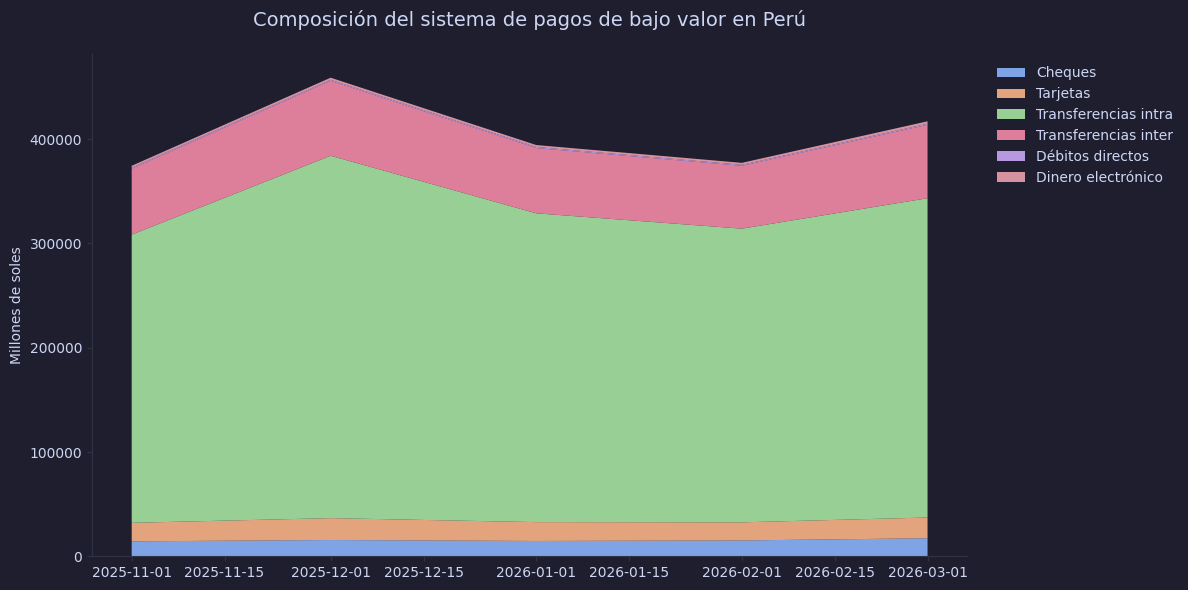

In [46]:
df_plot = (
    df_instr_alto_bajo_valor[
        [
            "period",
            "bajo_valor_cheques",
            "bajo_valor_tarjetas_pago",
            "bajo_valor_transferencias_intrabancarias",
            "bajo_valor_transferencias_interbancarias",
            "bajo_valor_debitos_directos",
            "bajo_valor_dinero_electronico",
        ]
    ]
    .query("period >= '2025-11-01'")
    .copy()
)

fig, ax = plt.subplots(figsize=(12, 6))

ax.stackplot(
    df_plot["period"],
    df_plot["bajo_valor_cheques"],
    df_plot["bajo_valor_tarjetas_pago"],
    df_plot["bajo_valor_transferencias_intrabancarias"],
    df_plot["bajo_valor_transferencias_interbancarias"],
    df_plot["bajo_valor_debitos_directos"],
    df_plot["bajo_valor_dinero_electronico"],
    labels=[
        "Cheques",
        "Tarjetas",
        "Transferencias intra",
        "Transferencias inter",
        "Débitos directos",
        "Dinero electrónico",
    ],
    alpha=0.9,
)

ax.set_title(
    "Composición del sistema de pagos de bajo valor en Perú", fontsize=14, pad=20
)

ax.set_ylabel("Millones de soles")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(
    frameon=False,
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

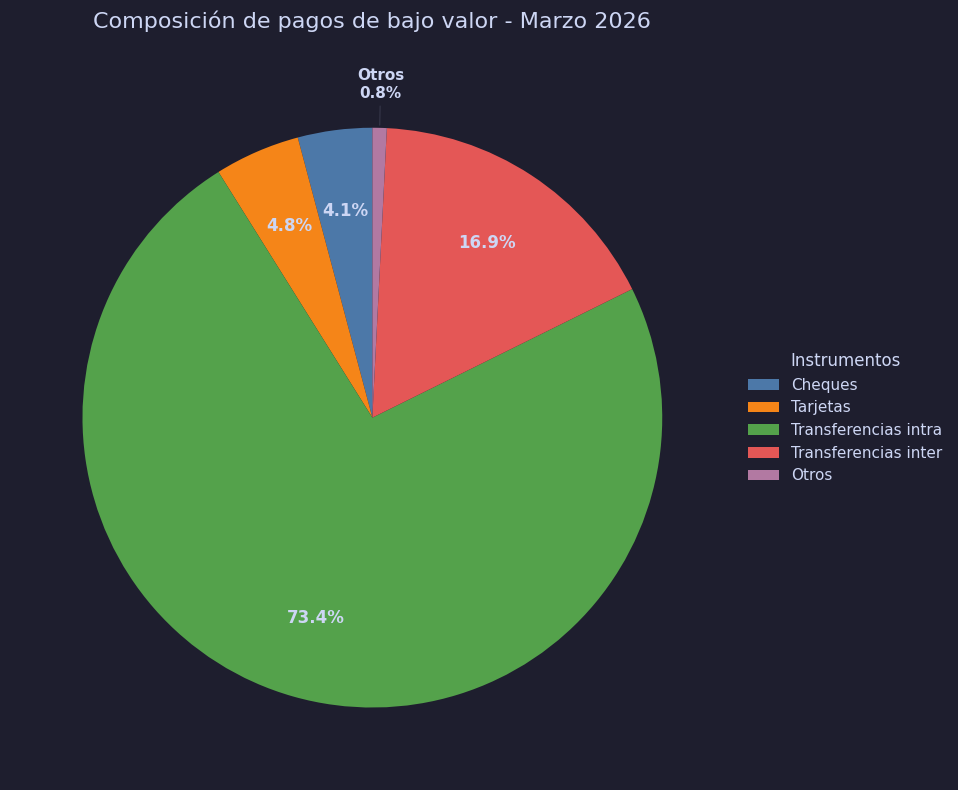

In [63]:
colors = [
    "#4c78a8",
    "#f58518",
    "#54a24b",
    "#e45756",
    "#b279a2",
]

df_pie = df_instr_alto_bajo_valor[
    df_instr_alto_bajo_valor["period"] == pd.Timestamp("2026-03-01")
]

otros = (
    df_pie["bajo_valor_debitos_directos"].values[0]
    + df_pie["bajo_valor_dinero_electronico"].values[0]
)

labels = [
    "Cheques",
    "Tarjetas",
    "Transferencias intra",
    "Transferencias inter",
    "Otros",
]

values = [
    df_pie["bajo_valor_cheques"].values[0],
    df_pie["bajo_valor_tarjetas_pago"].values[0],
    df_pie["bajo_valor_transferencias_intrabancarias"].values[0],
    df_pie["bajo_valor_transferencias_interbancarias"].values[0],
    otros,
]

fig, ax = plt.subplots(figsize=(10, 8))

wedges, texts, autotexts = ax.pie(
    values,
    autopct=lambda p: f"{p:.1f}%" if p > 2 else "",
    startangle=90,
    pctdistance=0.72,
    textprops={"fontsize": 12},
    colors=colors,
)

otros_pct = values[-1] / sum(values) * 100
wedge = wedges[-1]

angle = (wedge.theta2 + wedge.theta1) / 2

x = 1.15 * np.cos(np.deg2rad(angle))
y = 1.15 * np.sin(np.deg2rad(angle))

ax.annotate(
    f"Otros\n{otros_pct:.1f}%",
    xy=(np.cos(np.deg2rad(angle)), np.sin(np.deg2rad(angle))),
    xytext=(x, y),
    fontsize=11,
    fontweight="bold",
    ha="center",
    va="center",
    arrowprops=dict(arrowstyle="-"),
)

for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight("bold")

ax.legend(
    wedges,
    labels,
    title="Instrumentos",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    fontsize=11,
    title_fontsize=12,
)

ax.set_title(
    "Composición de pagos de bajo valor - Marzo 2026",
    fontsize=16,
    pad=20,
)

plt.tight_layout()
plt.show()